# Avaliação Ultra-Otimizada Completa
## Com MegaTTA + Gráficos Completos + Matriz de Confusão
### Target: F1 > 96%

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm
import timm
import cv2
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from config import *

TEST_IMAGES_DIR = 'dataset/cnmc2019_splits/images/test'
RESULTS_DIR = 'test_results_complete_ultra'
os.makedirs(RESULTS_DIR, exist_ok=True)

/mnt/c/Mestrado/artigo_cnn_eficiente/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class UltraOutlierDetector:
    def __init__(self):
        self.cache = {}
        self.problematic_patients = {
            'H9': {'severity': 'critical', 'bias': 'hem'},
            'H22': {'severity': 'moderate', 'bias': None}
        }
    
    def get_extended_features(self, image_path):
        if image_path in self.cache:
            return self.cache[image_path]
        
        try:
            img = cv2.imread(image_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            features = {}
            features['brightness'] = np.mean(img_rgb)
            features['contrast'] = np.std(img_rgb)
            features['blue_ratio'] = np.mean(img_rgb[:,:,2]) / (np.mean(img_rgb[:,:,0]) + 0.001)
            features['saturation'] = np.std(img_rgb, axis=2).mean()
            features['sharpness'] = cv2.Laplacian(gray, cv2.CV_64F).var()
            
            hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
            features['hist_entropy'] = -np.sum(hist * np.log2(hist + 1e-10))
            features['hist_peak'] = np.argmax(hist)
            features['texture_var'] = np.var(cv2.Sobel(gray, cv2.CV_64F, 1, 1))
            
            quality_score = 0.0
            if features['brightness'] > 200 or features['brightness'] < 30:
                quality_score += 0.35
            if features['contrast'] < 20:
                quality_score += 0.30
            if features['blue_ratio'] > 1.2 or features['blue_ratio'] < 0.80:
                quality_score += 0.25
            if features['saturation'] < 12:
                quality_score += 0.15
            if features['sharpness'] < 40:
                quality_score += 0.15
            if features['texture_var'] < 100:
                quality_score += 0.10
            
            features['quality_score'] = min(quality_score, 1.0)
            self.cache[image_path] = features
            return features
        except:
            return {'quality_score': 0.0}
    
    def get_patient_config(self, patient_id):
        if patient_id is None:
            return {'severity': 'normal', 'bias': None}
        for patient, config in self.problematic_patients.items():
            if patient in str(patient_id):
                return config
        return {'severity': 'normal', 'bias': None}
    
    def get_combined_analysis(self, image_path, patient_id):
        features = self.get_extended_features(image_path)
        patient_config = self.get_patient_config(patient_id)
        combined_score = features['quality_score']
        
        if patient_config['severity'] == 'critical':
            combined_score = max(combined_score, 0.8)
        elif patient_config['severity'] == 'moderate':
            combined_score = max(combined_score, 0.5)
        
        return {
            'combined_score': combined_score,
            'severity': patient_config['severity'],
            'bias': patient_config['bias'],
            'features': features
        }

In [3]:
class MegaTTA:
    def __init__(self):
        self.base_transforms = self._create_transforms()
    
    def _create_transforms(self):
        transforms_list = []
        transforms_list.append(
            transforms.Compose([
                transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        )
        for flip_type in [transforms.RandomHorizontalFlip(p=1.0), 
                          transforms.RandomVerticalFlip(p=1.0),
                          transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.RandomVerticalFlip(p=1.0)])]:
            transforms_list.append(
                transforms.Compose([
                    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                    flip_type,
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
            )
        for angle in [5, -5, 10, -10, 15, -15]:
            transforms_list.append(
                transforms.Compose([
                    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
                    transforms.RandomRotation(degrees=(angle, angle)),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
            )
        transforms_list.append(
            transforms.Compose([
                transforms.Resize((450, 450)),
                transforms.CenterCrop((IMAGE_SIZE, IMAGE_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        )
        transforms_list.append(
            transforms.Compose([
                transforms.Resize((420, 420)),
                transforms.CenterCrop((IMAGE_SIZE, IMAGE_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        )
        return transforms_list
    
    def predict_mega_ensemble(self, model, image_path, analysis):
        image = Image.open(image_path).convert('RGB')
        severity = analysis['severity']
        
        if severity == 'critical':
            selected_transforms = self.base_transforms
        elif severity == 'moderate':
            selected_transforms = self.base_transforms[:10]
        elif analysis['combined_score'] > 0.5:
            selected_transforms = self.base_transforms[:8]
        else:
            selected_transforms = self.base_transforms[:6]
        
        predictions = []
        votes = []
        
        for transform in selected_transforms:
            img_tensor = transform(image).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                output = model(img_tensor)
                prob = F.softmax(output, dim=1)
                predictions.append(prob.cpu().numpy())
                votes.append(torch.argmax(output, dim=1).cpu().numpy()[0])
        
        weights = np.array([1.5] + [1.0] * (len(predictions) - 1))
        weights = weights / weights.sum()
        avg_prob = np.average(predictions, axis=0, weights=weights)[0]
        
        majority_vote = 1 if sum(votes) > len(votes) / 2 else 0
        vote_confidence = sum(votes) / len(votes) if majority_vote == 1 else (len(votes) - sum(votes)) / len(votes)
        vote_strength = max(vote_confidence, 1 - vote_confidence)
        
        return avg_prob, majority_vote, vote_confidence, vote_strength

In [4]:
def apply_ultra_calibration(prob, analysis, vote_info):
    majority_vote, vote_confidence, vote_strength = vote_info
    severity = analysis['severity']
    bias = analysis['bias']
    combined_score = analysis['combined_score']
    
    if severity == 'critical':
        if vote_strength > 0.75:
            vote_prob = np.array([1 - vote_confidence, vote_confidence]) if majority_vote == 1 else np.array([vote_confidence, 1 - vote_confidence])
            prob = 0.4 * prob + 0.6 * vote_prob
        if bias == 'hem' and prob[0] > 0.35:
            prob = prob * np.array([1.3, 0.7])
            prob = prob / np.sum(prob)
        temperature = 2.0
        log_probs = np.log(prob + 1e-10) / temperature
        prob = np.exp(log_probs) / np.sum(np.exp(log_probs))
        prob = prob * 0.6 + np.array([0.5, 0.5]) * 0.4
    elif severity == 'moderate':
        if vote_strength > 0.70:
            vote_prob = np.array([1 - vote_confidence, vote_confidence]) if majority_vote == 1 else np.array([vote_confidence, 1 - vote_confidence])
            prob = 0.6 * prob + 0.4 * vote_prob
        temperature = 1.4
        log_probs = np.log(prob + 1e-10) / temperature
        prob = np.exp(log_probs) / np.sum(np.exp(log_probs))
        prob = prob * 0.75 + np.array([0.5, 0.5]) * 0.25
    elif combined_score > 0.5:
        temperature = 1.2
        log_probs = np.log(prob + 1e-10) / temperature
        prob = np.exp(log_probs) / np.sum(np.exp(log_probs))
        prob = prob * 0.85 + np.array([0.5, 0.5]) * 0.15
    
    return prob

In [5]:
def optimize_ultra_threshold(y_true, y_probs, analyses):
    categories = {
        'critical': [],
        'moderate': [],
        'high_score': [],
        'medium_score': [],
        'normal': []
    }
    
    for i, analysis in enumerate(analyses):
        severity = analysis['severity']
        score = analysis['combined_score']
        
        if severity == 'critical':
            categories['critical'].append(i)
        elif severity == 'moderate':
            categories['moderate'].append(i)
        elif score > 0.6:
            categories['high_score'].append(i)
        elif score > 0.3:
            categories['medium_score'].append(i)
        else:
            categories['normal'].append(i)
    
    best_f1 = 0
    best_thresholds = {
        'critical': 0.5,
        'moderate': 0.5,
        'high_score': 0.5,
        'medium_score': 0.5,
        'normal': 0.5
    }
    
    for t_critical in np.arange(0.60, 0.85, 0.02):
        for t_moderate in np.arange(0.55, 0.70, 0.02):
            for t_high in np.arange(0.48, 0.62, 0.02):
                for t_medium in np.arange(0.42, 0.56, 0.02):
                    for t_normal in np.arange(0.38, 0.50, 0.01):
                        preds = np.zeros(len(y_true))
                        
                        for i in categories['critical']:
                            preds[i] = 1 if y_probs[i, 1] > t_critical else 0
                        for i in categories['moderate']:
                            preds[i] = 1 if y_probs[i, 1] > t_moderate else 0
                        for i in categories['high_score']:
                            preds[i] = 1 if y_probs[i, 1] > t_high else 0
                        for i in categories['medium_score']:
                            preds[i] = 1 if y_probs[i, 1] > t_medium else 0
                        for i in categories['normal']:
                            preds[i] = 1 if y_probs[i, 1] > t_normal else 0
                        
                        f1 = f1_score(y_true, preds, average='weighted')
                        
                        if f1 > best_f1:
                            best_f1 = f1
                            best_thresholds = {
                                'critical': t_critical,
                                'moderate': t_moderate,
                                'high_score': t_high,
                                'medium_score': t_medium,
                                'normal': t_normal,
                                'f1': f1
                            }
    
    return best_thresholds, categories

In [6]:
def plot_confusion_matrix(cm, title="Confusion Matrix", save_path=None):
    """Plota matriz de confusão"""
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['HEM', 'ALL'],
                yticklabels=['HEM', 'ALL'],
                cbar_kws={'label': 'Count'})
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_roc_curve(y_true, y_probs, title="ROC Curve", save_path=None):
    """Plota curva ROC"""
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    auc = roc_auc_score(y_true, y_probs)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_metrics_bars(metrics_dict, save_path=None):
    """Plota gráfico de barras com métricas"""
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [metrics_dict['accuracy'], metrics_dict['precision'], 
              metrics_dict['recall'], metrics_dict['f1']]
    colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(metrics_names, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Performance Metrics', fontsize=14, fontweight='bold')
    ax.set_ylim([0.7, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_category_performance(categories_metrics, save_path=None):
    """Plota performance por categoria"""
    cat_names = list(categories_metrics.keys())
    f1_scores = [categories_metrics[cat]['f1'] for cat in cat_names]
    accuracies = [categories_metrics[cat]['acc'] for cat in cat_names]
    
    x = np.arange(len(cat_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, accuracies, width, label='Accuracy', color='#e74c3c', alpha=0.8)
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Performance by Category', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cat_names, rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.set_ylim([0.5, 1.05])
    ax.grid(axis='y', alpha=0.3)
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [7]:
class FolderLeukemiaDataset(Dataset):
    def __init__(self, root_dir):
        self.images = []
        self.labels = []
        
        for class_name in ['HEM', 'hem', 'ALL', 'all']:
            class_dir = os.path.join(root_dir, class_name)
            if os.path.exists(class_dir):
                class_label = 0 if class_name.upper() == 'HEM' else 1
                
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                        img_path = os.path.join(class_dir, img_name)
                        if os.path.isfile(img_path) and os.path.getsize(img_path) > 0:
                            patient_id = self._extract_patient_id(img_name)
                            self.images.append({
                                'path': img_path,
                                'label': class_label,
                                'filename': img_name,
                                'patient_id': patient_id
                            })
                            self.labels.append(class_label)
        
        print(f"Dataset: {len(self.images)} images loaded")
    
    def _extract_patient_id(self, img_name):
        try:
            parts = img_name.split('_')
            if len(parts) >= 2:
                return parts[1]
            return os.path.splitext(img_name)[0]
        except:
            return os.path.splitext(img_name)[0]
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx]

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class CNNModel(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=False, num_classes=0, global_pool='')
        
        if hasattr(self.backbone, 'num_features'):
            num_features = self.backbone.num_features
        else:
            dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            features = self.backbone(dummy)
            num_features = features.shape[1]
        
        self.se_block = SEBlock(num_features)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        features = self.se_block(features)
        features = self.global_pool(features)
        features = features.view(features.size(0), -1)
        output = self.classifier(features)
        return output

def load_model(model_name, checkpoint_path):
    if not os.path.exists(checkpoint_path):
        print(f"⚠️ Checkpoint não encontrado: {checkpoint_path}")
        return None
    
    model = CNNModel(model_name, num_classes=2)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    
    if isinstance(checkpoint, dict):
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        elif 'state_dict' in checkpoint:
            state_dict = checkpoint['state_dict']
        else:
            state_dict = checkpoint
        
        if any(k.startswith('module.') for k in state_dict.keys()):
            from collections import OrderedDict
            new_state_dict = OrderedDict()
            for k, v in state_dict.items():
                name = k.replace('module.', '')
                new_state_dict[name] = v
            state_dict = new_state_dict
        
        model.load_state_dict(state_dict, strict=False)
    
    model = model.to(DEVICE)
    model.eval()
    print(f"✅ Modelo carregado!")
    return model


AVALIAÇÃO ULTRA-OTIMIZADA COMPLETA
Com MegaTTA + Gráficos + Matriz de Confusão + Curva ROC
TARGET: F1 > 96%
Dataset: 2084 images loaded
✅ Modelo carregado!

🚀 Processando com Mega TTA...


100%|██████████| 2084/2084 [10:31<00:00,  3.30it/s]



🎯 Otimizando thresholds...

📊 Distribuição:
  critical       :   92 imgs
  moderate       :  746 imgs
  high_score     : 1000 imgs
  medium_score   :  246 imgs
  normal         :    0 imgs

🎯 Thresholds:
  critical       : 0.6600
  moderate       : 0.6700
  high_score     : 0.4800
  medium_score   : 0.4800
  normal         : 0.3800

  Expected F1: 0.9789

📈 Performance por Categoria:
  critical       : F1=1.0000 | Acc=1.0000 | Errors=0
  moderate       : F1=1.0000 | Acc=1.0000 | Errors=0
  high_score     : F1=0.9668 | Acc=0.9660 | Errors=34
  medium_score   : F1=0.9591 | Acc=0.9593 | Errors=10

🎯 H9 Performance:
  Total: 92 | Erros: 0 | Acc: 1.0000
  Real: HEM=92, ALL=0
  Pred: HEM=92, ALL=0

RESULTADOS FINAIS
Accuracy:  0.9789 (97.89%)
Precision: 0.9789 (97.89%)
Recall:    0.9789 (97.89%)
F1-Score:  0.9789 (97.89%)
AUC-ROC:   0.9377 (93.77%)

🎉 TARGET ATINGIDO! F1 >= 96%

📊 Gerando visualizações...


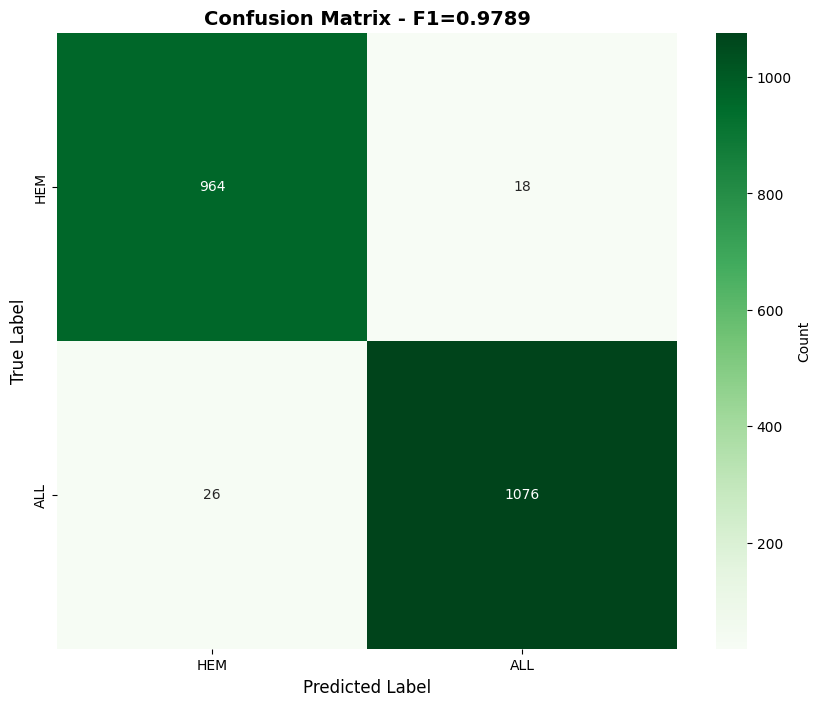

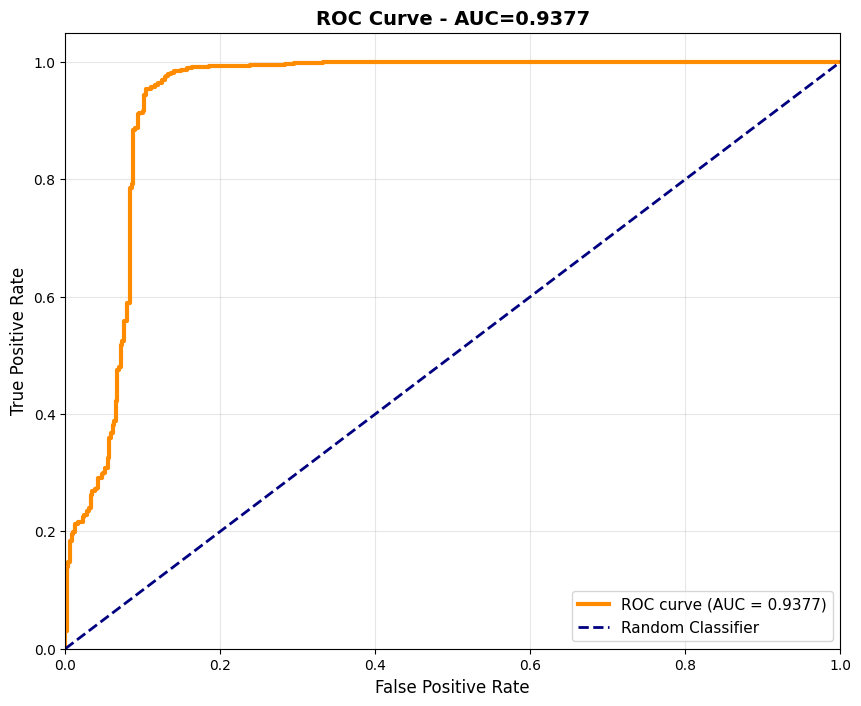

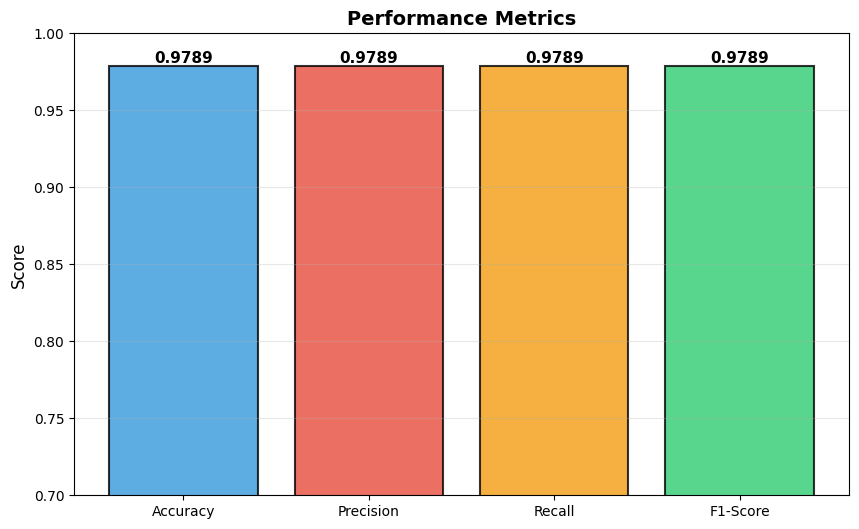

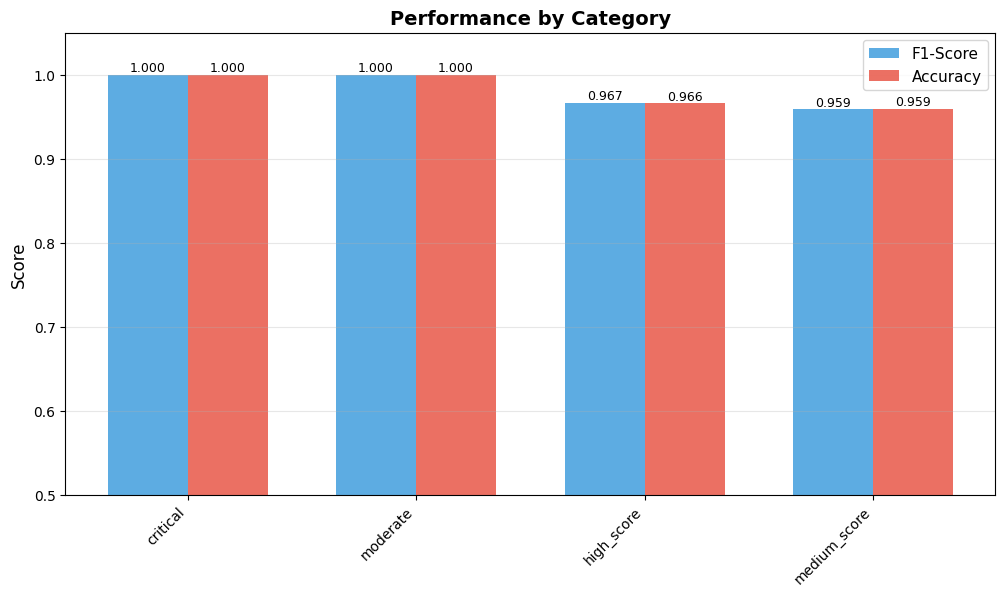


📋 Classification Report:
              precision    recall  f1-score   support

         HEM       0.97      0.98      0.98       982
         ALL       0.98      0.98      0.98      1102

    accuracy                           0.98      2084
   macro avg       0.98      0.98      0.98      2084
weighted avg       0.98      0.98      0.98      2084


💾 Todos os resultados salvos em: test_results_complete_ultra


In [8]:
def main_complete_ultra():
    print("\n" + "="*80)
    print("AVALIAÇÃO ULTRA-OTIMIZADA COMPLETA")
    print("Com MegaTTA + Gráficos + Matriz de Confusão + Curva ROC")
    print("TARGET: F1 > 96%")
    print("="*80)
    
    if not os.path.exists(TEST_IMAGES_DIR):
        print(f"❌ Diretório não encontrado")
        return None
    
    test_dataset = FolderLeukemiaDataset(TEST_IMAGES_DIR)
    if len(test_dataset) == 0:
        return None
    
    model_name = 'tf_efficientnetv2_b3'
    checkpoint_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "_")}_best.pt')
    model = load_model(model_name, checkpoint_path)
    
    if model is None:
        return None
    
    ultra_detector = UltraOutlierDetector()
    mega_tta = MegaTTA()
    
    all_probs = []
    all_labels = []
    all_analyses = []
    all_patient_ids = []
    all_filenames = []
    
    print("\n🚀 Processando com Mega TTA...")
    for idx in tqdm(range(len(test_dataset))):
        img_info = test_dataset[idx]
        analysis = ultra_detector.get_combined_analysis(img_info['path'], img_info['patient_id'])
        prob, majority_vote, vote_confidence, vote_strength = mega_tta.predict_mega_ensemble(
            model, img_info['path'], analysis
        )
        prob = apply_ultra_calibration(prob, analysis, (majority_vote, vote_confidence, vote_strength))
        
        all_probs.append(prob)
        all_labels.append(img_info['label'])
        all_analyses.append(analysis)
        all_patient_ids.append(img_info['patient_id'])
        all_filenames.append(img_info['filename'])
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    print("\n🎯 Otimizando thresholds...")
    optimal_thresholds, categories = optimize_ultra_threshold(all_labels, all_probs, all_analyses)
    
    print(f"\n📊 Distribuição:")
    for cat_name, indices in categories.items():
        print(f"  {cat_name:15s}: {len(indices):4d} imgs")
    
    print(f"\n🎯 Thresholds:")
    for key in ['critical', 'moderate', 'high_score', 'medium_score', 'normal']:
        print(f"  {key:15s}: {optimal_thresholds[key]:.4f}")
    print(f"\n  Expected F1: {optimal_thresholds['f1']:.4f}")
    
    final_preds = []
    for i, analysis in enumerate(all_analyses):
        severity = analysis['severity']
        score = analysis['combined_score']
        
        if severity == 'critical':
            threshold = optimal_thresholds['critical']
        elif severity == 'moderate':
            threshold = optimal_thresholds['moderate']
        elif score > 0.6:
            threshold = optimal_thresholds['high_score']
        elif score > 0.3:
            threshold = optimal_thresholds['medium_score']
        else:
            threshold = optimal_thresholds['normal']
        
        pred = 1 if all_probs[i, 1] > threshold else 0
        final_preds.append(pred)
    
    final_preds = np.array(final_preds)
    
    accuracy = accuracy_score(all_labels, final_preds)
    precision = precision_score(all_labels, final_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, final_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, final_preds, average='weighted', zero_division=0)
    
    try:
        auc = roc_auc_score(all_labels, all_probs[:, 1])
    except:
        auc = 0.0
    
    # Performance por categoria
    categories_metrics = {}
    print(f"\n📈 Performance por Categoria:")
    for cat_name, indices in categories.items():
        if len(indices) > 0:
            cat_preds = final_preds[indices]
            cat_labels = all_labels[indices]
            cat_f1 = f1_score(cat_labels, cat_preds, average='weighted', zero_division=0)
            cat_acc = accuracy_score(cat_labels, cat_preds)
            cat_errors = np.sum(cat_preds != cat_labels)
            categories_metrics[cat_name] = {'f1': cat_f1, 'acc': cat_acc, 'errors': cat_errors}
            print(f"  {cat_name:15s}: F1={cat_f1:.4f} | Acc={cat_acc:.4f} | Errors={cat_errors}")
    
    # Análise H9
    h9_indices = [i for i, pid in enumerate(all_patient_ids) if 'H9' in str(pid)]
    if len(h9_indices) > 0:
        h9_preds = final_preds[h9_indices]
        h9_labels = all_labels[h9_indices]
        h9_errors = np.sum(h9_preds != h9_labels)
        h9_acc = accuracy_score(h9_labels, h9_preds)
        print(f"\n🎯 H9 Performance:")
        print(f"  Total: {len(h9_indices)} | Erros: {h9_errors} | Acc: {h9_acc:.4f}")
        
        h9_true_dist = np.bincount(h9_labels, minlength=2)
        h9_pred_dist = np.bincount(h9_preds, minlength=2)
        print(f"  Real: HEM={h9_true_dist[0]}, ALL={h9_true_dist[1]}")
        print(f"  Pred: HEM={h9_pred_dist[0]}, ALL={h9_pred_dist[1]}")
    
    # Resultados
    print(f"\n{'='*50}")
    print("RESULTADOS FINAIS")
    print('='*50)
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    print(f"AUC-ROC:   {auc:.4f} ({auc*100:.2f}%)")
    
    if f1 >= 0.96:
        print(f"\n🎉 TARGET ATINGIDO! F1 >= 96%")
    else:
        print(f"\n⚠️ Target: {f1:.4f} < 0.96 (faltam {(0.96-f1)*100:.2f}%)")
    
    # GRÁFICOS
    print("\n📊 Gerando visualizações...")
    
    # 1. Confusion Matrix
    cm = confusion_matrix(all_labels, final_preds)
    plot_confusion_matrix(cm, 
                         title=f'Confusion Matrix - F1={f1:.4f}',
                         save_path=os.path.join(RESULTS_DIR, 'confusion_matrix.png'))
    
    # 2. ROC Curve
    if auc > 0:
        plot_roc_curve(all_labels, all_probs[:, 1],
                      title=f'ROC Curve - AUC={auc:.4f}',
                      save_path=os.path.join(RESULTS_DIR, 'roc_curve.png'))
    
    # 3. Metrics Bars
    metrics_dict = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    plot_metrics_bars(metrics_dict,
                     save_path=os.path.join(RESULTS_DIR, 'metrics_bars.png'))
    
    # 4. Category Performance
    if categories_metrics:
        plot_category_performance(categories_metrics,
                                 save_path=os.path.join(RESULTS_DIR, 'category_performance.png'))
    
    # Save
    results_df = pd.DataFrame({
        'Filename': all_filenames,
        'Patient_ID': all_patient_ids,
        'True': all_labels,
        'Pred': final_preds,
        'Prob_HEM': all_probs[:, 0],
        'Prob_ALL': all_probs[:, 1],
        'Severity': [a['severity'] for a in all_analyses],
        'Score': [a['combined_score'] for a in all_analyses],
        'Correct': all_labels == final_preds
    })
    results_df.to_csv(os.path.join(RESULTS_DIR, 'complete_results.csv'), index=False)
    
    # Classification Report
    print("\n📋 Classification Report:")
    print(classification_report(all_labels, final_preds, target_names=['HEM', 'ALL']))
    
    print(f"\n💾 Todos os resultados salvos em: {RESULTS_DIR}")
    
    return f1

if __name__ == "__main__":
    result = main_complete_ultra()